# Заняття 02 — Python для Data Engineering

## Основні цілі заняття:
* Показати як працювати з різними джерелами даних (REST-api, file-based).
* Поглянути на основні бібліотеки для **локальної** роботи з даними в Python (`pandas` і `polars`) і побачити основну різницю між ними (парадигма, синтаксис, performance).
* Швидко поглянути на Data Quality в локальній роботі з даними
* Провести __exploratory data analysis__ основного датасету та загалом познайомитися з ним

* **Датасет:** NYC TLC Yellow Taxi Trip Records, January 2024
* **Формат:** Parquet (~100 MB, ~3 млн рядків)
* **Довідник зон:** NYC TLC Taxi Zone Lookup (265 рядків)

## 1. Отримання даних через REST API (Socrata / NYC Open Data)

NYC Open Data надає TLC taxi-дані через **Socrata REST API**.
Той самий домен — `PULocationID` / `DOLocationID` — але доступ через HTTP JSON.

Типовий REST API flow:
1. `GET` запит з query-параметрами
2. Парсинг JSON-відповіді
3. Пагінація через `$offset`
4. Збереження у внутрішній формат (Parquet)

**SoQL** (Socrata Query Language) — SQL-подібні параметри в URL:
`$where`, `$select`, `$order`, `$limit`, `$offset`

App token (опціонально, збільшує rate limit):
https://data.cityofnewyork.us/profile/app_tokens

In [2]:
import os
from io import StringIO
from pathlib import Path

import pandas as pd
import requests

LANDING_DIR = Path("../../data/lesson-02/landing/")
REFERENCE_DIR = Path("../../data/lesson-02/reference")
LANDING_DIR.mkdir(parents=True, exist_ok=True)
REFERENCE_DIR.mkdir(parents=True, exist_ok=True)

# Yellow Taxi Trip Data 2019 on NYC Open Data
# ⚠️ Verify dataset ID at: https://data.cityofnewyork.us (search "Yellow Taxi Trip Data")
SOCRATA_BASE = "https://data.cityofnewyork.us/resource"
DATASET_ID = "2upf-qytp"

APP_TOKEN = os.getenv("SOCRATA_APP_TOKEN")
headers = {"X-App-Token": APP_TOKEN} if APP_TOKEN else {}

### GET-запит з SoQL параметрами

In [3]:
params = {
    "$select": "PULocationID,DOLocationID,trip_distance,fare_amount,passenger_count,tpep_pickup_datetime",
    "$where": "trip_distance > 10 AND fare_amount > 0",
    "$order": "fare_amount DESC",
    "$limit": 500,
}

resp = requests.get(
    f"{SOCRATA_BASE}/{DATASET_ID}.json",
    params=params,
    headers=headers,
    timeout=30,
)
resp.raise_for_status()

In [4]:
from icecream import ic
ic(resp.status_code, resp.headers.get("Content-Type"), len(resp.json()))

ic| resp.status_code: 200
    resp.headers.get("Content-Type"): 'application/json;charset=utf-8'
    len(resp.json()): 500


(200, 'application/json;charset=utf-8', 500)

Тіло відповіді — список JSON-об'єктів (перші два):

In [5]:
resp.json()

[{'PULocationID': '138',
  'DOLocationID': '181',
  'trip_distance': '10.60',
  'fare_amount': '671123.14',
  'passenger_count': '1',
  'tpep_pickup_datetime': '2019-02-25T18:43:23.000'},
 {'PULocationID': '132',
  'DOLocationID': '225',
  'trip_distance': '10.80',
  'fare_amount': '9434',
  'passenger_count': '1',
  'tpep_pickup_datetime': '2019-04-20T17:22:25.000'},
 {'PULocationID': '141',
  'DOLocationID': '162',
  'trip_distance': '100.80',
  'fare_amount': '8000.3',
  'passenger_count': '1',
  'tpep_pickup_datetime': '2019-01-12T23:21:48.000'},
 {'PULocationID': '193',
  'DOLocationID': '193',
  'trip_distance': '17.00',
  'fare_amount': '2759.07',
  'passenger_count': '1',
  'tpep_pickup_datetime': '2019-09-05T15:34:19.000'},
 {'PULocationID': '193',
  'DOLocationID': '193',
  'trip_distance': '17.00',
  'fare_amount': '2759.07',
  'passenger_count': '1',
  'tpep_pickup_datetime': '2019-09-05T15:33:18.000'},
 {'PULocationID': '193',
  'DOLocationID': '193',
  'trip_distance': '1

### Парсинг у DataFrame

Socrata повертає всі поля як рядки — потрібен явний cast числових колонок.

In [6]:
df_api = pd.DataFrame(resp.json())

for col in ["PULocationID", "DOLocationID", "passenger_count"]:
    df_api[col] = pd.to_numeric(df_api[col], errors="coerce").astype("Int64")
for col in ["trip_distance", "fare_amount"]:
    df_api[col] = pd.to_numeric(df_api[col], errors="coerce")
df_api["tpep_pickup_datetime"] = pd.to_datetime(df_api["tpep_pickup_datetime"])

ic(df_api.shape)

ic| df_api.shape: (500, 6)


(500, 6)

In [7]:
df_api.head(3)

,PULocationID,DOLocationID,trip_distance,fare_amount,passenger_count,tpep_pickup_datetime
0,138,181,10.6,671123.14,1,2019-02-25 18:43:23
1,132,225,10.8,9434.00,1,2019-04-20 17:22:25
2,141,162,100.8,8000.30,1,2019-01-12 23:21:48


### Пагінація через `$offset`

Socrata повертає максимум 1000 рядків за запит.
Для більшого обсягу — посторінкова вибірка.

In [8]:
PAGE_SIZE = 500
MAX_PAGES = 3
page_params = {
    "$select": "PULocationID,DOLocationID,trip_distance,fare_amount,tpep_pickup_datetime",
    "$where": "trip_distance > 5 AND fare_amount > 0",
    "$order": "tpep_pickup_datetime ASC",
}

pages = []
for page in range(MAX_PAGES):
    r = requests.get(
        f"{SOCRATA_BASE}/{DATASET_ID}.json",
        params={**page_params, "$limit": PAGE_SIZE, "$offset": page * PAGE_SIZE},
        headers=headers,
        timeout=30,
    )
    r.raise_for_status()
    batch = r.json()
    if not batch:
        break
    pages.append(pd.DataFrame(batch))
    ic(page, len(batch))

df_paged = pd.concat(pages, ignore_index=True)
ic(len(df_paged))

ic| page: 0, len(batch): 500
ic| page: 1, len(batch): 500
ic| page: 2, len(batch): 500
ic| len(df_paged): 1500


1500

### Довідник зон — збереження у Parquet

Зберігаємо Parquet замість CSV:
- менший розмір завдяки колонковому стисненню
- типи зберігаються явно (не потрібен зайвий cast при читанні)
- predicate pushdown у downstream запитах

In [9]:
ZONE_PARQUET = REFERENCE_DIR / "taxi_zone_lookup.parquet"
ZONE_CSV_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

r_zones = requests.get(ZONE_CSV_URL, timeout=30)
r_zones.raise_for_status()
df_zones = pd.read_csv(StringIO(r_zones.text))
df_zones.to_parquet(ZONE_PARQUET, index=False)

csv_kb = len(r_zones.content) / 1e3
parquet_kb = ZONE_PARQUET.stat().st_size / 1e3
ic(csv_kb, parquet_kb)

ic| csv_kb: 12.331, parquet_kb: 8.032


(12.331, 8.032)

### Join: API-дані + довідник зон

`PULocationID` з Socrata збігається з `LocationID` у zone lookup —
той самий ключ, що і в основному Parquet-датасеті (розділ 2).

In [10]:
zones = pd.read_parquet(ZONE_PARQUET).rename(
    columns={"LocationID": "PULocationID", "Zone": "PU_Zone"}
)[["PULocationID", "PU_Zone"]]

df_api_joined = df_api.merge(zones, on="PULocationID", how="left")
df_api_joined[["PU_Zone", "fare_amount", "trip_distance"]].head(5)

,PU_Zone,fare_amount,trip_distance
0,LaGuardia Airport,671123.14,10.6
1,JFK Airport,9434.00,10.8
2,Lenox Hill West,8000.30,100.8
3,Queensbridge/Ravenswood,2759.07,17.0
4,Queensbridge/Ravenswood,2759.07,17.0


Топ зон відправлення у вибірці:

In [11]:
df_api_joined["PU_Zone"].value_counts().head(10)



PU_Zone
JFK Airport                     228
Outside of NYC                   33
LaGuardia Airport                26
Penn Station/Madison Sq West     21
Baisley Park                     13
South Ozone Park                 10
Garment District                  8
Clinton East                      8
East Chelsea                      7
West Chelsea/Hudson Yards         5
Name: count, dtype: int64

## 2. Завантаження основного датасету

NYC TLC Yellow Taxi Trip Records за January 2024.
Файл: `data/landing/yellow_tripdata_2024-01.parquet` (~100 MB, ~3 млн рядків)

Скрипт **ідемпотентний** — повторний запуск нічого не перезаписує.

In [12]:
YEAR, MONTH = 2024, 1
BASE_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data"
PARQUET_PATH = LANDING_DIR / f"yellow_tripdata_{YEAR}-{MONTH:02d}.parquet"
url = f"{BASE_URL}/{PARQUET_PATH.name}"

if PARQUET_PATH.exists():
    ic(PARQUET_PATH, PARQUET_PATH.stat().st_size / 1e6)
else:
    ic(url)
    r = requests.get(url, stream=True, timeout=120)
    r.raise_for_status()
    with open(PARQUET_PATH, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    ic(PARQUET_PATH, PARQUET_PATH.stat().st_size / 1e6)



ic| url: 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet'
ic| PARQUET_PATH: PosixPath('../../data/lesson-02/landing/yellow_tripdata_2024-01.parquet')
    PARQUET_PATH.stat().st_size / 1e6: 49.961641


Дані можна було б не зберігати на локальному диску - іноді такий підхід теж корисний. `pandas` надає можливість читати дані прямо з URL:

In [13]:
pd.read_parquet(url).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

## 3. Інспекція схеми без завантаження даних

`pq.read_schema` читає тільки **footer** Parquet-файлу — метадані колонок,
але не самі рядки. Дешева перевірка перед початком роботи.

In [14]:
import pyarrow.parquet as pq

EXPECTED_COLUMNS = {
    "VendorID", "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "RatecodeID",
    "PULocationID", "DOLocationID", "payment_type",
    "fare_amount", "tip_amount", "total_amount",
    "congestion_surcharge", "Airport_fee",
}

actual_schema = pq.read_schema(PARQUET_PATH)
actual_cols = set(actual_schema.names)
missing = EXPECTED_COLUMNS - actual_cols

In [15]:
ic(len(actual_cols), missing or "немає")

ic| len(actual_cols): 19, missing or "немає": 'немає'


(19, 'немає')

Повна схема:

In [16]:
actual_schema



VendorID: int32
tpep_pickup_datetime: timestamp[us]
tpep_dropoff_datetime: timestamp[us]
passenger_count: int64
trip_distance: double
RatecodeID: int64
store_and_fwd_flag: large_string
PULocationID: int32
DOLocationID: int32
payment_type: int64
fare_amount: double
extra: double
mta_tax: double
tip_amount: double
tolls_amount: double
improvement_surcharge: double
total_amount: double
congestion_surcharge: double
Airport_fee: double

## 4. Pandas: читання Parquet

`pd.read_parquet` зчитує весь файл у пам'ять (**eager evaluation**).

In [17]:
df = pd.read_parquet(PARQUET_PATH)

In [18]:
ic(df.shape, df.memory_usage(deep=True).sum() / 1e6)

ic| df.shape: (2964624, 19)
    df.memory_usage(deep=True).sum() / 1e6: np.float64(535.917488)


((2964624, 19), np.float64(535.917488))

In [19]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object

За замовчуванням, `pandas` використовує `numpy` для репрезентації даних в **оперативній памʼяті**.

In [20]:
type(df.dtypes["VendorID"])

numpy.dtypes.Int32DType

### Arrow-backed pandas (pandas 2.x)

`dtype_backend="pyarrow"` зберігає колонки в форматі Apache Arrow **всередині оперативної памʼяті**. 

Поширений міф: «Arrow завжди зменшує пам'ять у pandas». Насправді — **не завжди**.
`memory_usage(deep=True)` може показати більше для Arrow-backend через Arrow-metadata overhead.
Виграш залежить від типів і розподілу даних; для числових датасетів різниця мінімальна.

Реальні переваги Arrow-backend у pandas:

1. **Потужніша система типів**: nullable integers без float-кастингу (`int64[pyarrow]`, не `float64`),
   точний `decimal128` для фінансових розрахунків, нативні `date32` / `time32`.
2. **Інтероперабельність**: Polars нативно читає Arrow-буфери — конвертація zero-copy,
   без зайнього копіювання даних у пам'яті.

In [21]:
df_arrow = pd.read_parquet(PARQUET_PATH, dtype_backend="pyarrow")
mem_default = df.memory_usage(deep=True).sum() / 1e6
mem_arrow = df_arrow.memory_usage(deep=True).sum() / 1e6

In [22]:
ic(mem_default, mem_arrow)

ic| mem_default: np.float64(535.917488)
    mem_arrow: np.float64(424.650792)


(np.float64(535.917488), np.float64(424.650792))

Arrow dtypes (порівняйте `passenger_count`: `float64` → `int64[pyarrow]`):

In [23]:
df_arrow.dtypes.head(6)

VendorID                         int32[pyarrow]
tpep_pickup_datetime     timestamp[us][pyarrow]
tpep_dropoff_datetime    timestamp[us][pyarrow]
passenger_count                  int64[pyarrow]
trip_distance                   double[pyarrow]
RatecodeID                       int64[pyarrow]
dtype: object

In [24]:
type(df_arrow.dtypes["VendorID"])

pandas.core.dtypes.dtypes.ArrowDtype

## 5. Polars: lazy evaluation

In [25]:
import sys
import time
import polars as pl

### Arrow → Polars: zero-copy конвертація

Polars нативно читає Arrow-буфери. З numpy-backend pandas змушений копіювати дані;
з Arrow-backend — ні. Це практичний сценарій, де Arrow-backend у pandas виправданий.

In [26]:
t0 = time.perf_counter()
_ = pl.from_pandas(df)
t_numpy_conv = time.perf_counter() - t0

t0 = time.perf_counter()
_ = pl.from_pandas(df_arrow)
t_arrow_conv = time.perf_counter() - t0

In [27]:
ic(t_numpy_conv, t_arrow_conv)
ic(t_numpy_conv / t_arrow_conv)

ic| t_numpy_conv: 0.18784450000384822
    t_arrow_conv: 0.10796370900061447
ic| t_numpy_conv / t_arrow_conv: 1.739885575835294


1.739885575835294

### Lazy evaluation

`pl.scan_parquet` **не читає дані** — будує LazyFrame (план запиту).
Дані матеріалізуються тільки при `.collect()`.

Одна з головних переваг це можливість проаналізувати трансформації що відбуваються в скрипті та оптимізувати їх заздалегідь.

In [28]:
lazy = pl.scan_parquet(PARQUET_PATH)

In [29]:
ic(sys.getsizeof(lazy))

ic| sys.getsizeof(lazy): 48


48

Також така парадигма роботи дозволяє Polars використовувати нативні для Parquet або інших джерел даних оптимізації як **predicate pushdown** (фільтрація даних ДО зчитування).

In [30]:
filtered_lazy = (
    lazy
    .filter(pl.col("fare_amount") > 0)
    .filter(pl.col("passenger_count") > 0)
    .select(["tpep_pickup_datetime", "PULocationID", "fare_amount", "trip_distance"])
)

Оптимізований план запиту (видно predicate pushdown):

In [31]:
print(filtered_lazy.explain(optimized=True))

simple π 4/4 ["tpep_pickup_datetime", ... 3 other columns]
  Parquet SCAN [../../data/lesson-02/landing/yellow_tripdata_2024-01.parquet]
  PROJECT 5/19 COLUMNS
  SELECTION: [([(col("fare_amount")) > (0.0)]) & ([(col("passenger_count")) > (0)])]
  ESTIMATED ROWS: 2964624


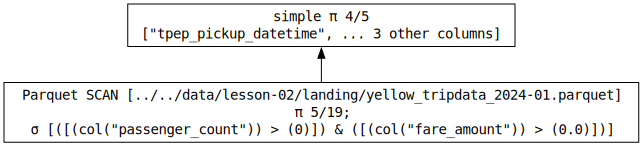

In [32]:
filtered_lazy.show_graph(optimized=True)

Для того щоб виконати обчислення (прочитати дані з фільтром у даному випадку) треба викликати функцію `collect`.

In [33]:
df_pl = filtered_lazy.collect()

In [34]:
ic(df_pl.shape, sys.getsizeof(df_pl) / 1e6)

ic| df_pl.shape: (2756810, 4), sys.getsizeof(df_pl) / 1e6: 4.8e-05


((2756810, 4), 4.8e-05)

In [35]:
df_pl.head(3)



tpep_pickup_datetime,PULocationID,fare_amount,trip_distance
datetime[ns],i32,f64,f64
2024-01-01 00:57:55,186,17.7,1.72
2024-01-01 00:03:00,140,10.0,1.8
2024-01-01 00:17:06,236,23.3,4.7


## 6. Benchmark: Pandas vs Polars

Та сама задача для обох бібліотек:
- `filter(fare_amount > 0)`
- `groupby(PULocationID).mean(fare_amount)`

**Predicate pushdown** тут показує себе в усій красі

In [36]:
t0 = time.perf_counter()
df_pd = pd.read_parquet(PARQUET_PATH)
result_pd = df_pd[df_pd["fare_amount"] > 0].groupby("PULocationID")["fare_amount"].mean()
t_pandas = time.perf_counter() - t0

t0 = time.perf_counter()
result_pl = (
    pl.scan_parquet(PARQUET_PATH)
    .filter(pl.col("fare_amount") > 0)
    .group_by("PULocationID")
    .agg(pl.col("fare_amount").mean().alias("avg_fare"))
    .collect()
)
t_polars = time.perf_counter() - t0

In [37]:
pd.DataFrame({
    "Бібліотека": ["Pandas", "Polars"],
    "Час (с)": [round(t_pandas, 2), round(t_polars, 2)],
    "Зон": [len(result_pd), len(result_pl)],
})

,Бібліотека,Час (с),Зон
0,Pandas,0.43,260
1,Polars,0.04,260


**Важливе зауваження**: `polars` не є гарантією того що Ви завжди будете мати blazingly fast data processing (наприклад, нижче ми будемо постійно пере-скановувати dataframe, через що швидкість може падати). Але за умови правильного використання ви зможете як ефективно використовувати памʼять, так й ефективніше використовувати CPU.

## 7. Основні операції: Pandas vs Polars

Кожну операцію показуємо в обох бібліотеках.
Pandas — eager, знайомий синтаксис.
Polars — lazy за замовчуванням, виразний API, швидший на великих даних.

In [38]:
lf = pl.scan_parquet(PARQUET_PATH)

### Filter

Залишаємо тільки денні поїздки (7:00–18:59).

In [39]:
daytime_pd = df[
    (df["tpep_pickup_datetime"].dt.hour >= 7) &
    (df["tpep_pickup_datetime"].dt.hour < 19)
]
ic(len(daytime_pd))

ic| len(daytime_pd): 1935183


1935183

In [40]:
daytime_pl = (
    lf.filter(pl.col("tpep_pickup_datetime").dt.hour().is_between(7, 18))
    .collect()
)
ic(len(daytime_pl))

ic| len(daytime_pl): 1935183


1935183

### Add column

Додаємо `hour` і `is_weekend` на основі часу відправлення.

In [41]:
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["is_weekend"] = df["tpep_pickup_datetime"].dt.dayofweek >= 5
df[["tpep_pickup_datetime", "hour", "is_weekend"]].head(3)

,tpep_pickup_datetime,hour,is_weekend
0,2024-01-01 00:57:55,0,False
1,2024-01-01 00:03:00,0,False
2,2024-01-01 00:17:06,0,False


In [42]:
df_with_cols = (
    lf.with_columns([
        pl.col("tpep_pickup_datetime").dt.hour().alias("hour"),
        (pl.col("tpep_pickup_datetime").dt.weekday() >= 5).alias("is_weekend"),
    ])
    .collect()
)
df_with_cols[["tpep_pickup_datetime", "hour", "is_weekend"]].head(3)

tpep_pickup_datetime,hour,is_weekend
datetime[ns],i8,bool
2024-01-01 00:57:55,0,false
2024-01-01 00:03:00,0,false
2024-01-01 00:17:06,0,false


### Join

Додаємо назву зони відправлення (`PU_Zone`) з довідника.
Довідник уже в Parquet — зберегли його на кроці 1 (REST API завантаження).

In [43]:
zones_pd = pd.read_parquet(ZONE_PARQUET).rename(
    columns={"LocationID": "PULocationID", "Zone": "PU_Zone"}
)[["PULocationID", "PU_Zone"]]
df_joined_pd = df.merge(zones_pd, on="PULocationID", how="left")
df_joined_pd["PU_Zone"].value_counts().head(5)

PU_Zone
JFK Airport              145240
Midtown Center           143471
Upper East Side South    142708
Upper East Side North    136465
Midtown East             106717
Name: count, dtype: int64

In [44]:
zones_pl = pl.read_parquet(ZONE_PARQUET).rename(
    {"LocationID": "PULocationID", "Zone": "PU_Zone"}
).select(["PULocationID", "PU_Zone"])
df_joined_pl = lf.join(zones_pl.lazy(), on="PULocationID", how="left").collect()
df_joined_pl["PU_Zone"].value_counts().head(5)

PU_Zone,count
str,u32
"""Penn Station/Madison Sq West""",104523
"""East New York""",938
"""Ocean Parkway South""",61
"""Springfield Gardens North""",337
"""Seaport""",4481


### Group by

Середній тариф і кількість поїздок по годині доби.

In [45]:
by_hour_pd = (
    df.groupby("hour")["fare_amount"]
    .agg(["mean", "count"])
    .reset_index()
    .sort_values("hour")
)
by_hour_pd

,hour,mean,count
0,0,19.202658,79094
1,1,17.527296,53627
2,2,16.482882,37517
3,3,18.150135,24811
4,4,22.518645,16742
5,5,26.619918,18764
6,6,21.650399,41429
7,7,18.539180,83719
8,8,17.654683,117209
9,9,17.708415,128970


In [46]:
by_hour_lf = (lf.with_columns(pl.col("tpep_pickup_datetime").dt.hour().alias("hour"))
    .group_by("hour")
    .agg([
        pl.col("fare_amount").mean().alias("mean"),
        pl.col("fare_amount").count().alias("count"),
    ])
    .sort("hour"))

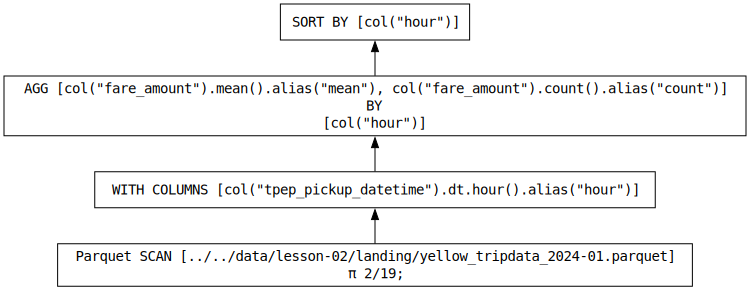

In [47]:
by_hour_lf.show_graph(optimized=True)

In [48]:
by_hour_pl = (
    by_hour_lf 
    .collect()
)
by_hour_pl

hour,mean,count
i8,f64,u32
0,19.202658,79094
1,17.527296,53627
2,16.482882,37517
3,18.150135,24811
4,22.518645,16742
…,…,…
19,17.294794,184032
20,17.695375,159989
21,17.954276,160888


### Window function

Rolling 3-годинне середнє по погодинній виручці.

In [49]:
hourly_pd = df.groupby("hour")["fare_amount"].sum().reset_index().sort_values("hour")
hourly_pd["rolling_3h_avg"] = hourly_pd["fare_amount"].rolling(window=3, min_periods=1).mean()
hourly_pd

,hour,fare_amount,rolling_3h_avg
0,0,1518815.04,1.518815e+06
1,1,939936.29,1.229376e+06
2,2,618388.29,1.025713e+06
3,3,450322.99,6.695492e+05
4,4,377007.16,4.819061e+05
5,5,499496.15,4.422754e+05
6,6,896954.38,5.911526e+05
7,7,1552081.62,9.828441e+05
8,8,2069287.71,1.506108e+06
9,9,2283854.33,1.968408e+06


In [50]:
hourly_lf = (lf.with_columns(pl.col("tpep_pickup_datetime").dt.hour().alias("hour"))
    .group_by("hour")
    .agg(pl.col("fare_amount").sum().alias("total_fare"))
    .sort("hour")
    .with_columns(
        pl.col("total_fare").rolling_mean(window_size=3, min_samples=1).alias("rolling_3h_avg")
    ))

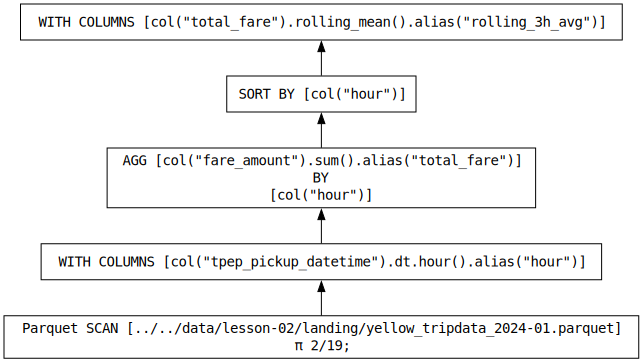

In [51]:
hourly_lf.show_graph(optimized=True)

In [52]:
hourly_pl = (
    hourly_lf
    .collect()
)
hourly_pl

hour,total_fare,rolling_3h_avg
i8,f64,f64
0,1.5188e6,1.5188e6
1,939936.29,1.2294e6
2,618388.29,1.0257e6
3,450322.99,669549.19
4,377007.16,481906.146667
…,…,…
19,3.1828e6,3.4735e6
20,2.8311e6,3.1908e6
21,2.8886e6,2.9675e6


### Union (concat)

Симулюємо об'єднання двох місяців — зсуваємо Jan на ~1 місяць для демо.

In [53]:
jan_pd = pd.read_parquet(PARQUET_PATH)
feb_pd = jan_pd.sample(100_000, random_state=42).copy()
feb_pd["tpep_pickup_datetime"] = feb_pd["tpep_pickup_datetime"] + pd.DateOffset(months=1)
feb_pd["tpep_dropoff_datetime"] = feb_pd["tpep_dropoff_datetime"] + pd.DateOffset(months=1)
combined_pd = pd.concat([jan_pd, feb_pd], ignore_index=True)
ic(len(jan_pd), len(feb_pd), len(combined_pd))

ic| len(jan_pd): 2964624
    len(feb_pd): 100000
    len(combined_pd): 3064624


(2964624, 100000, 3064624)

In [54]:
jan_pl = pl.read_parquet(PARQUET_PATH)
feb_pl = jan_pl.sample(100_000, seed=42).with_columns([
    pl.col("tpep_pickup_datetime").dt.offset_by("1mo"),
    pl.col("tpep_dropoff_datetime").dt.offset_by("1mo"),
])
combined_pl = pl.concat([jan_pl, feb_pl])
ic(len(jan_pl), len(feb_pl), len(combined_pl))



ic| len(jan_pl): 2964624
    len(feb_pl): 100000
    len(combined_pl): 3064624


(2964624, 100000, 3064624)

## 8. EDA: пошук первинного ключа

Чи є природний унікальний ідентифікатор поїздки?

In [55]:
lf.head(10).collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0
1,2024-01-01 00:54:08,2024-01-01 01:26:31,1,4.7,1,"""N""",148,141,1,29.6,3.5,0.5,6.9,0.0,1.0,41.5,2.5,0.0
2,2024-01-01 00:49:44,2024-01-01 01:15:47,2,10.82,1,"""N""",138,181,1,45.7,6.0,0.5,10.0,0.0,1.0,64.95,0.0,1.75
1,2024-01-01 00:30:40,2024-01-01 00:58:40,0,3.0,1,"""N""",246,231,2,25.4,3.5,0.5,0.0,0.0,1.0,30.4,2.5,0.0
2,2024-01-01 00:26:01,2024-01-01 00:54:12,1,5.44,1,"""N""",161,261,2,31.0,1.0,0.5,0.0,0.0,1.0,36.0,2.5,0.0


In [56]:
candidate = ["VendorID","tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance", "PULocationID", "DOLocationID", "fare_amount"]

(
    lf.select(candidate)
      .group_by(candidate)
      .len()
      .filter(pl.col("len") > 1)
      .collect()
)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,PULocationID,DOLocationID,fare_amount,len
i32,datetime[ns],datetime[ns],f64,i32,i32,f64,u32
2,2024-01-30 11:42:54,2024-01-30 11:45:00,0.27,114,144,0.0,2
2,2024-01-08 07:43:18,2024-01-08 07:43:34,0.0,13,13,0.0,2
2,2024-01-24 20:22:21,2024-01-24 20:23:02,0.06,137,137,0.0,2
2,2024-01-20 02:08:14,2024-01-20 02:18:19,1.51,158,231,0.0,2
2,2024-01-13 17:12:41,2024-01-13 17:12:57,0.0,138,138,0.0,2
…,…,…,…,…,…,…,…
2,2024-01-30 18:50:31,2024-01-30 19:16:44,0.0,13,239,0.0,2
2,2024-01-16 08:53:14,2024-01-16 09:23:37,0.0,132,132,0.0,2
2,2024-01-04 15:54:12,2024-01-04 16:17:27,9.41,170,138,0.0,2


In [57]:
duplicated_rows = lf.filter(
    pl.struct(lf.columns[:-3]).is_duplicated()
)

/var/folders/3b/r7klmkpj5sj4vxwp9m43y5x80000gn/T/ipykernel_96426/1162049181.py:2: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  pl.struct(lf.columns[:-3]).is_duplicated()


In [58]:
lf.columns[:-3]

/var/folders/3b/r7klmkpj5sj4vxwp9m43y5x80000gn/T/ipykernel_96426/2419768353.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  lf.columns[:-3]


['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge']

In [59]:
duplicated_rows.collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64


### Аналіз типів даних

Перевіряємо типи колонок — чи відповідають вони семантиці поля?

In [60]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
hour                              int32
is_weekend                         bool
dtype: object

`PULocationID` — int, `fare_amount` — float64 (USD), `passenger_count` — float64 через nullable (краще було б Int8).

### DQ по п'яти осях

#### Accuracy — чи значення відповідають реальності?

In [61]:
neg_fares = df[df["fare_amount"] < 0]
ic(len(neg_fares))

ic| len(neg_fares): 37448


37448

In [62]:
df["duration_h"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 3600
df["speed_mph"] = df["trip_distance"] / df["duration_h"].replace(0, float("nan"))
fast = df[df["speed_mph"] > 200]
ic(len(fast))

ic| len(fast): 830


830

#### Completeness — відсутні значення

In [63]:
nulls = df.isnull().sum()
nulls[nulls > 0]

passenger_count         140162
RatecodeID              140162
store_and_fwd_flag      140162
congestion_surcharge    140162
Airport_fee             140162
speed_mph                  814
dtype: int64

#### Consistency — внутрішня узгодженість

In [64]:
time_anomaly = df[df["tpep_pickup_datetime"] >= df["tpep_dropoff_datetime"]]
ic(len(time_anomaly))

ic| len(time_anomaly): 870


870

#### Timeliness — чи дати в очікуваному діапазоні?

In [65]:
ic(df["tpep_pickup_datetime"].min(), df["tpep_pickup_datetime"].max())

ic| df["tpep_pickup_datetime"].min(): Timestamp('2002-12-31 22:59:39')
    df["tpep_pickup_datetime"].max(): Timestamp('2024-02-01 00:01:15')


(Timestamp('2002-12-31 22:59:39'), Timestamp('2024-02-01 00:01:15'))

In [66]:
out_of_range = df[df["tpep_pickup_datetime"].dt.year != 2024]
ic(len(out_of_range))

ic| len(out_of_range): 15


15

#### Validity — значення в допустимих межах?

In [67]:
zero_pax = df[df["passenger_count"].isin([0]) | df["passenger_count"].isna()]
ic(len(zero_pax))

ic| len(zero_pax): 171627


171627

In [68]:
invalid_pu = df[(df["PULocationID"] > 265) | (df["PULocationID"] < 1)]
ic(len(invalid_pu))

ic| len(invalid_pu): 0


0

### Статистичний аналіз

In [69]:
df[["fare_amount", "trip_distance", "passenger_count", "duration_h"]].describe()

,fare_amount,trip_distance,passenger_count,duration_h
count,2.964624e+06,2.964624e+06,2.824462e+06,2.964624e+06
mean,1.817506e+01,3.652169e+00,1.339281e+00,2.602158e-01
std,1.894955e+01,2.254626e+02,8.502817e-01,5.808509e-01
min,-8.990000e+02,0.000000e+00,0.000000e+00,-2.261111e-01
25%,8.600000e+00,1.000000e+00,1.000000e+00,1.191667e-01
50%,1.280000e+01,1.680000e+00,1.000000e+00,1.938889e-01
75%,2.050000e+01,3.110000e+00,1.000000e+00,3.113889e-01
max,5.000000e+03,3.127223e+05,9.000000e+00,1.575900e+02


### Візуалізація (seaborn)

Фільтруємо очевидні аномалії для кращої читаності графіків.

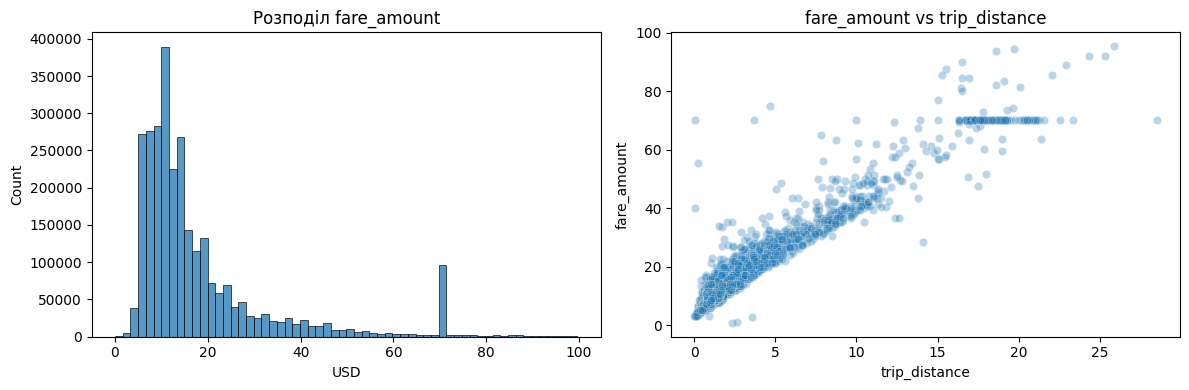

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

clean = df[
    (df["fare_amount"] > 0) & (df["fare_amount"] < 100) &
    (df["trip_distance"] > 0) & (df["trip_distance"] < 50)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(clean["fare_amount"], bins=60, ax=axes[0])
axes[0].set_title("Розподіл fare_amount")
axes[0].set_xlabel("USD")

sns.scatterplot(
    data=clean.sample(3_000, random_state=42),
    x="trip_distance",
    y="fare_amount",
    alpha=0.3,
    ax=axes[1],
)
axes[1].set_title("fare_amount vs trip_distance")

plt.tight_layout()
plt.savefig("data/eda_plots.png", dpi=100)
plt.show()



## 9. Геопросторовий вимір (GeoPandas)

NYC TLC надає межи таксі-зон у форматі Shapefile (ZIP).
GeoPandas дозволяє робити **spatial joins** — та сама логіка, що й у звичайних DataFrame.

Завантажуємо Shapefile з TLC CloudFront,
об'єднуємо з кількістю поїздок і будуємо хороплет-карту.

In [71]:
import io
import os
import tempfile
import zipfile
import geopandas as gpd

ZONES_ZIP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"

_r = requests.get(ZONES_ZIP_URL)
with tempfile.TemporaryDirectory() as _tmp:
    with zipfile.ZipFile(io.BytesIO(_r.content)) as _z:
        _z.extractall(_tmp)
    _shp = next(
        os.path.join(root, f)
        for root, _, files in os.walk(_tmp)
        for f in files if f.endswith(".shp")
    )
    gdf_zones = gpd.read_file(_shp)
gdf_zones = gdf_zones.rename(columns={"LocationID": "location_id"})

In [72]:
ic(gdf_zones.shape)

ic| gdf_zones.shape: (263, 7)


(263, 7)

In [73]:
gdf_zones[["location_id", "zone", "borough", "geometry"]].head(3)

,location_id,zone,borough,geometry
0,1,Newark Airport,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,Jamaica Bay,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,Allerton/Pelham Gardens,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."


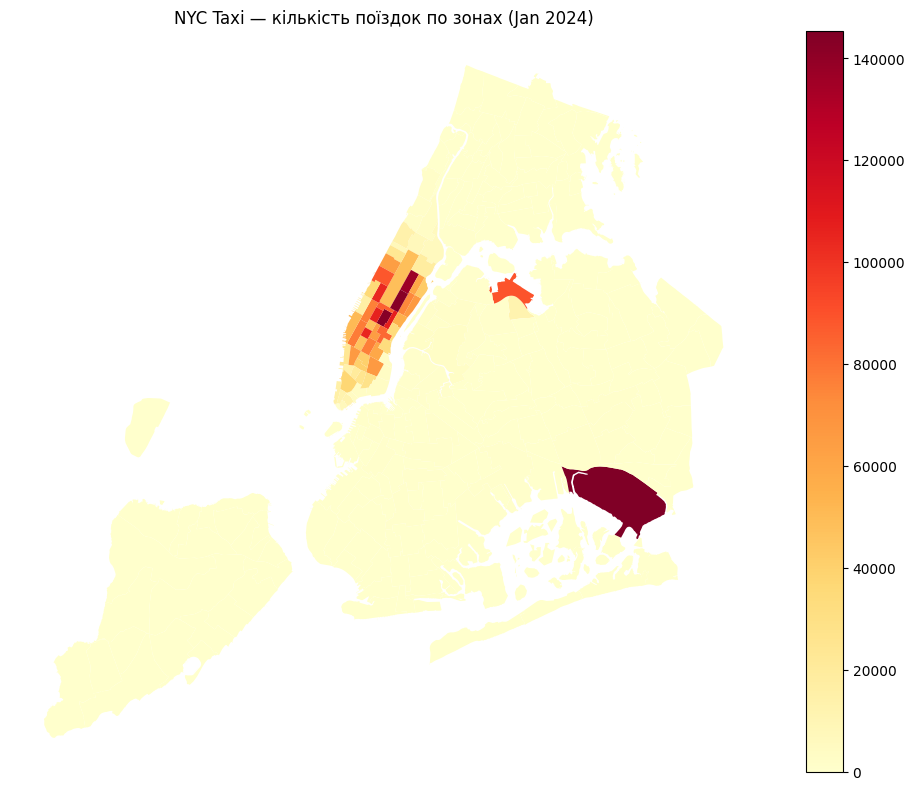

In [74]:
pickup_counts = (
    df.groupby("PULocationID")
    .size()
    .reset_index(name="trip_count")
    .assign(location_id=lambda x: x["PULocationID"].astype(str))
)
gdf_zones["location_id"] = gdf_zones["location_id"].astype(str)
gdf_with_trips = gdf_zones.merge(pickup_counts, on="location_id", how="left")
gdf_with_trips["trip_count"] = gdf_with_trips["trip_count"].fillna(0)

fig, ax = plt.subplots(figsize=(10, 8))
gdf_with_trips.plot(column="trip_count", cmap="YlOrRd", legend=True, ax=ax)
ax.set_title("NYC Taxi — кількість поїздок по зонах (Jan 2024)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("data/nyc_taxi_heatmap.png", dpi=100)
plt.show()